# 🎨 Fine-Tuning Stable Diffusion 3.5 with LoRA
Welcome to this notebook! Here, we'll be training a Low-Rank Adaptation (LoRA) model on top of **Stable Diffusion 3.5 Medium**. This approach allows us to teach the model new concepts (like specific interior design styles) without needing massive amounts of compute.

### 📝 What we'll cover:
1. Environment setup and library installation.
2. Dataset preparation and validation.
3. Configuring training hyperparameters.
4. Launching the training process.
5. Generating test images with our new LoRA!
6. Exporting the final model to Kaggle Datasets.

Let's dive in! 🚀

## 🛠️ 1. Environment Setup
First things first, let's make sure we have a capable GPU assigned and install all the necessary libraries like `diffusers`, `transformers`, `peft`, and `accelerate`.

In [5]:
!pip install -U diffusers transformers accelerate peft bitsandbytes torchao Pillow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.2/5.2 MB 56.0 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 108.6 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 383.7/383.7 kB 21.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 680.7/680.7 kB 29.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 32.9 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 101.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 663.6/663.6 kB 33.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 509.1/509.1 kB 34.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 97.3 MB/s eta 0:00:00:00:01
  Attempting uninstall: torchao
    Found existing installation: torchao 0.10.0
    Uninstalling torchao-0.10.0:
      Successfully uninstalled torchao-0.10.0
  Attempting uninstall: safetensors
    Found existing installation: safetensors 0.7.0
   

In [1]:
!nvidia-smi

Sun May 17 06:24:55 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.105.08             Driver Version: 580.105.08     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   36C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [1]:
import os
import subprocess
from pathlib import Path

repo_url = "https://github.com/seochan99/stable-diffusion-3.5-text2image-lora.git"
workspace = Path("/kaggle/working/")
repo_path = workspace / "stable-diffusion-3.5-text2image-lora"

if not repo_path.exists():
    subprocess.run(["git", "clone", repo_url, str(repo_path)], check=True)

os.chdir(repo_path)
print("Working directory:", Path.cwd())

Cloning into '/kaggle/working/stable-diffusion-3.5-text2image-lora'...


Working directory: /kaggle/working/stable-diffusion-3.5-text2image-lora


In [2]:
from pathlib import Path

# TODO: update these paths to match your setup
DATA_ROOT = Path("/kaggle/input/datasets/mneebahmd/interior-design/dataset")
OUTPUT_DIR = Path("/kaggle/working/sd35_lora")

# Example if you mounted Drive
# DATA_ROOT = Path("/content/drive/MyDrive/datasets/my_project")
# OUTPUT_DIR = Path("/content/drive/MyDrive/experiments/sd35-lora")

DATA_ROOT.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Dataset directory:", DATA_ROOT)
print("Output directory:", OUTPUT_DIR)

Dataset directory: /kaggle/input/datasets/mneebahmd/interior-design/dataset
Output directory: /kaggle/working/sd35_lora


## 📂 2. Data Preparation
A model is only as good as its data! Here, we will:
* Set up our workspace and output directories.
* Verify that our images and `metadata.jsonl` files are present and correctly formatted.

If you don't see your dataset printing out below, double-check your Kaggle input paths!

In [3]:
import json
from itertools import islice

metadata_path = DATA_ROOT / "metadata.jsonl"
if metadata_path.exists():
    print("✅ Found metadata file:", metadata_path)
    with open(metadata_path, "r", encoding="utf-8") as fp:
        preview = list(islice(fp, 3))
    if preview:
        print("First metadata entries:")
        for line in preview:
            print(" ", line.strip())
else:
    print("⚠️ metadata.jsonl not found yet. Upload your dataset before training.")

images_dir = DATA_ROOT / "images"
if images_dir.exists():
    sample_images = sorted(images_dir.glob("*"))[:3]
    total_images = len(list(images_dir.glob("*")))
    print(f"Found {total_images} image files. Showing up to 3:")
    for path in sample_images:
        print(" ", path.name)
else:
    print("⚠️ images/ directory not found yet.")

✅ Found metadata file: /kaggle/input/datasets/mneebahmd/interior-design/dataset/metadata.jsonl
First metadata entries:
  {"image": "images/original_97b6acf1-2eb9-4671-95eb-8331a99db358.jpg", "caption": "A professionally designed Lounge featuring a Sleek Charcoal color theme and a Neutral color palette. The Natural Daylight lighting enhances the overall Home Theater atmosphere."}
  {"image": "images/original_55726fd2-1468-4e21-bbf4-f93d993db9b9.jpeg", "caption": "A professionally designed Lounge featuring a Earthy Terracotta color theme and a Warm color palette. The Warm Indoor Lighting lighting enhances the overall Cozy Family atmosphere."}
  {"image": "images/original_d2d840ff-5762-42e4-98c8-737bab4c133f.jpeg", "caption": "A professionally designed Lounge featuring a Modern White color theme and a Neutral color palette. The Warm Indoor Lighting lighting enhances the overall Cozy Family atmosphere."}
Found 2056 image files. Showing up to 3:
  horizontal_flip_00649c89-e4c3-428c-a96e-a74

## ⚙️ 3. Training Configuration
Now for the fun part: tuning the hyperparameters. We are defining a configuration dictionary here so everything is in one easy-to-edit place.

**Key Parameters to watch:**
* `rank`: Higher rank means higher expressive power, but larger file size. (We're using 16).
* `learning_rate`: Set to `8e-5`, a solid starting point for SD3.5 LoRAs.
* `max_train_steps`: The total number of optimization steps.

In [5]:
training_config = {
    "pretrained_model_name_or_path": "tensorart/stable-diffusion-3.5-medium-turbo",

    "train_data_dir": str(DATA_ROOT),
    "output_dir": str(OUTPUT_DIR),

    # More detail
    "resolution": 512,

    "train_batch_size": 1,
    "gradient_accumulation_steps": 4,

    "num_train_epochs": 10,
    "max_train_steps": 1500,

    # Higher expressive power
    "rank": 16,

    "learning_rate": 8e-5,
    "text_encoder_lr": 0,

    "lr_scheduler": "cosine",
    "lr_warmup_steps": 200,

    "mixed_precision": "fp16",

    "validation_prompt": None,
    "validation_epochs": None,
    "num_validation_images": 0,

    "checkpointing_steps": 500,

    "report_to": None,

    "dataloader_num_workers": 2,

    "seed": 42,

    "precondition_outputs": 1,
}

flag_args = {
    "center_crop": False,
    "random_flip": True,

    "use_8bit_adam": True,

    "gradient_checkpointing": True,

    "train_text_encoder": False,
}

### 🧠 A Quick Note on Memory Optimization
Since we're running this on Kaggle's free-tier GPUs (those trusty dual T4s only have 16GB of VRAM each!), we need to be a little strategic about our memory usage. 

Stable Diffusion 3.5 uses three text encoders, and the **T5xxl encoder** is *massive*. To make sure we don't run out of memory and crash our session, we've specifically configured the script to drop the T5 encoder during training. This gives us maximum memory efficiency while still getting fantastic fine-tuning results from the remaining CLIP encoders. It's a lifesaver for free-tier training! 🙌

In [4]:
%%writefile train_sd35_lora.py
#!/usr/bin/env python
# coding=utf-8
# Copyright 2025 Seochan99. All rights reserved.
#
# Licensed under the Apache License, Version 2.0 (the "License");
# you may not use this file except in compliance with the License.
# You may obtain a copy of the License at
#
#     http://www.apache.org/licenses/LICENSE-2.0
#
# Unless required by applicable law or agreed to in writing, software
# distributed under the License is distributed on an "AS IS" BASIS,
# WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
# See the License for the specific language governing permissions and
# limitations under the License.

"""
Stable Diffusion 3.5 Text-to-Image LoRA Fine-tuning Script

A comprehensive implementation for fine-tuning Stable Diffusion 3.5 models using LoRA adapters.
Supports both transformer and text encoder LoRA training with advanced features like:
- Mixed precision training (FP16/BF16)
- Gradient checkpointing for memory efficiency
- Custom weighting schemes for timestep sampling
- Distributed training support
- Comprehensive validation and logging

Author: Seochan99
"""

import argparse
import os
import math
import copy
import itertools
import shutil
from contextlib import nullcontext
import gc

import torch
from torch.utils.data import DataLoader

import transformers
from transformers import (
    CLIPTokenizer,
    PretrainedConfig,
    T5TokenizerFast,
)

import diffusers
from diffusers import (
    AutoencoderKL,
    SD3Transformer2DModel,
    StableDiffusion3Pipeline,
)
from diffusers.optimization import get_scheduler
from diffusers.training_utils import (
    cast_training_params,
    compute_density_for_timestep_sampling,
    compute_loss_weighting_for_sd3,
    free_memory,
)
from diffusers.utils.torch_utils import is_compiled_module

from accelerate import Accelerator, DistributedType
from accelerate.logging import get_logger
from accelerate.utils import (
    DistributedDataParallelKwargs,
    ProjectConfiguration,
    set_seed,
)

from datasets import load_dataset

from peft import LoraConfig, set_peft_model_state_dict
from peft.utils import get_peft_model_state_dict

from PIL import Image
from PIL.ImageOps import exif_transpose
from torchvision import transforms
from tqdm.auto import tqdm

# Optional dependencies
try:
    import wandb

    _WANDB_AVAILABLE = True
except ImportError:
    _WANDB_AVAILABLE = False


def parse_args():
    """Parse command line arguments for SD3.5 LoRA training configuration."""
    parser = argparse.ArgumentParser(
        description="Stable Diffusion 3.5 LoRA Fine-tuning"
    )

    # ═══════════════════════════════════════════════════════════
    # Model and Dataset Configuration
    # ═══════════════════════════════════════════════════════════
    parser.add_argument(
        "--pretrained_model_name_or_path",
        type=str,
        required=True,
        help="Path to pretrained SD3.5 model or HuggingFace Hub identifier",
    )
    parser.add_argument(
        "--revision",
        type=str,
        default=None,
        help="Specific model revision to use (branch name, tag, or commit hash)",
    )
    parser.add_argument(
        "--variant",
        type=str,
        default=None,
        help="Model weight variant (e.g., 'fp16')",
    )

    parser.add_argument(
        "--dataset_name",
        type=str,
        default=None,
        help="HuggingFace Dataset name for training data",
    )
    parser.add_argument(
        "--train_data_dir",
        type=str,
        default=None,
        help="Local directory containing metadata.jsonl and images folder",
    )
    parser.add_argument(
        "--image_column",
        type=str,
        default="image",
        help="Column name for image paths in the dataset",
    )
    parser.add_argument(
        "--caption_column",
        type=str,
        default="caption",
        help="Column name for captions in the dataset",
    )
    parser.add_argument(
        "--cache_dir",
        type=str,
        default=None,
        help="Directory to cache HuggingFace models and datasets",
    )

    # ═══════════════════════════════════════════════════════════
    # Output Configuration
    # ═══════════════════════════════════════════════════════════
    parser.add_argument(
        "--output_dir",
        type=str,
        default="outputs/sd3-lora",
        help="Directory to save model checkpoints and LoRA weights",
    )
    parser.add_argument(
        "--logging_dir",
        type=str,
        default="logs",
        help="TensorBoard logging directory (relative to output_dir)",
    )

    # ═══════════════════════════════════════════════════════════
    # Training Configuration
    # ═══════════════════════════════════════════════════════════
    parser.add_argument(
        "--resolution",
        type=int,
        default=1024,
        help="Training image resolution (images will be resized to this size)",
    )
    parser.add_argument(
        "--center_crop",
        action="store_true",
        help="Use center crop instead of random crop for image preprocessing",
    )
    parser.add_argument(
        "--random_flip",
        action="store_true",
        help="Apply random horizontal flip augmentation during training",
    )
    parser.add_argument(
        "--train_batch_size",
        type=int,
        default=4,
        help="Training batch size per device",
    )
    parser.add_argument(
        "--num_train_epochs",
        type=int,
        default=1,
        help="Number of training epochs",
    )
    parser.add_argument(
        "--max_train_steps",
        type=int,
        default=None,
        help="Maximum number of training steps (overrides num_train_epochs if set)",
    )
    parser.add_argument(
        "--gradient_accumulation_steps",
        type=int,
        default=1,
        help="Number of gradient accumulation steps before optimizer update",
    )
    parser.add_argument(
        "--learning_rate",
        type=float,
        default=1e-4,
        help="Learning rate for transformer LoRA parameters",
    )
    parser.add_argument(
        "--text_encoder_lr",
        type=float,
        default=5e-6,
        help="Learning rate for text encoder LoRA parameters",
    )
    parser.add_argument(
        "--scale_lr",
        action="store_true",
        default=False,
        help="Scale learning rate by number of GPUs, gradient accumulation steps, and batch size",
    )

    # ═══════════════════════════════════════════════════════════
    # LoRA Configuration
    # ═══════════════════════════════════════════════════════════
    parser.add_argument(
        "--rank",
        type=int,
        default=4,
        help="LoRA rank (dimensionality of adapter matrices)",
    )
    parser.add_argument(
        "--lora_layers",
        type=str,
        default=None,
        help="Comma-separated list of layer names (e.g., 'attn.to_q','ff.net.0.proj') to apply LoRA to within selected blocks. If --lora_blocks is not set, these apply to standard transformer attention modules.",
    )
    parser.add_argument(
        "--lora_blocks",
        type=str,
        default=None,
        help="Comma-separated list of transformer block indices (e.g., '0,1,5') to apply LoRA to. If specified, --lora_layers will be prefixed with 'transformer_blocks.{idx}.'. If None, default LoRA targets are used.",
    )

    # ═══════════════════════════════════════════════════════════
    # Validation Configuration
    # ═══════════════════════════════════════════════════════════
    parser.add_argument(
        "--validation_prompt",
        type=str,
        default=None,
        help="Prompt for generating validation images during training",
    )
    parser.add_argument(
        "--num_validation_images",
        type=int,
        default=4,
        help="Number of validation images to generate",
    )
    parser.add_argument(
        "--validation_epochs",
        type=int,
        default=50,
        help="Run validation every N epochs",
    )

    # ═══════════════════════════════════════════════════════════
    # Advanced Training Configuration
    # ═══════════════════════════════════════════════════════════
    parser.add_argument(
        "--mixed_precision",
        type=str,
        default=None,
        choices=["no", "fp16", "bf16"],
        help="Mixed precision training mode",
    )
    parser.add_argument(
        "--lr_scheduler",
        type=str,
        default="constant",
        help="Learning rate scheduler type",
    )
    parser.add_argument(
        "--lr_warmup_steps",
        type=int,
        default=500,
        help="Number of learning rate warmup steps",
    )
    parser.add_argument(
        "--lr_num_cycles",
        type=int,
        default=1,
        help="Number of learning rate cycles for cosine_with_restarts scheduler",
    )
    parser.add_argument(
        "--lr_power",
        type=float,
        default=1.0,
        help="Power factor for polynomial scheduler",
    )

    # ═══════════════════════════════════════════════════════════
    # Optimizer Configuration
    # ═══════════════════════════════════════════════════════════
    parser.add_argument(
        "--optimizer",
        type=str,
        default="adamw",
        help="Optimizer type: 'adamw' or 'prodigy'",
    )
    parser.add_argument(
        "--use_8bit_adam",
        action="store_true",
        help="Use 8-bit AdamW optimizer (requires bitsandbytes)",
    )
    parser.add_argument(
        "--adam_beta1",
        type=float,
        default=0.9,
        help="Adam/Prodigy optimizer beta1 parameter",
    )
    parser.add_argument(
        "--adam_beta2",
        type=float,
        default=0.999,
        help="Adam/Prodigy optimizer beta2 parameter",
    )
    parser.add_argument(
        "--prodigy_beta3",
        type=float,
        default=None,
        help="Prodigy optimizer beta3 parameter",
    )
    parser.add_argument(
        "--prodigy_decouple",
        type=bool,
        default=True,
        help="Use decoupled weight decay in Prodigy optimizer",
    )
    parser.add_argument(
        "--adam_weight_decay",
        type=float,
        default=1e-4,
        help="Weight decay for transformer parameters",
    )
    parser.add_argument(
        "--adam_weight_decay_text_encoder",
        type=float,
        default=1e-3,
        help="Weight decay for text encoder parameters",
    )
    parser.add_argument(
        "--adam_epsilon",
        type=float,
        default=1e-8,
        help="Epsilon value for Adam/Prodigy optimizers",
    )
    parser.add_argument(
        "--prodigy_use_bias_correction",
        type=bool,
        default=True,
        help="Enable bias correction in Prodigy optimizer",
    )
    parser.add_argument(
        "--prodigy_safeguard_warmup",
        type=bool,
        default=True,
        help="Enable safeguard warmup in Prodigy optimizer",
    )
    parser.add_argument(
        "--max_grad_norm",
        default=1.0,
        type=float,
        help="Maximum gradient norm for clipping",
    )

    # ═══════════════════════════════════════════════════════════
    # System and Logging Configuration
    # ═══════════════════════════════════════════════════════════
    parser.add_argument(
        "--seed",
        type=int,
        default=None,
        help="Random seed for reproducible training",
    )
    parser.add_argument(
        "--max_train_samples",
        type=int,
        default=None,
        help="Maximum number of training samples (for debugging)",
    )
    parser.add_argument(
        "--checkpoints_total_limit",
        type=int,
        default=None,
        help="Maximum number of checkpoints to keep",
    )
    parser.add_argument(
        "--checkpointing_steps",
        type=int,
        default=500,
        help="Save checkpoint every N steps",
    )
    parser.add_argument(
        "--resume_from_checkpoint",
        type=str,
        default=None,
        help="Path to checkpoint for resuming training, or 'latest' for most recent",
    )
    parser.add_argument(
        "--gradient_checkpointing",
        action="store_true",
        help="Enable gradient checkpointing to reduce memory usage",
    )
    parser.add_argument(
        "--train_text_encoder",
        action="store_true",
        help="Whether to train text encoder LoRA adapters",
    )
    parser.add_argument(
        "--dataloader_num_workers",
        type=int,
        default=0,
        help="Number of DataLoader worker processes",
    )
    parser.add_argument(
        "--local_rank",
        type=int,
        default=-1,
        help="Local rank for distributed training",
    )
    parser.add_argument(
        "--report_to",
        type=str,
        default="tensorboard",
        help="Logging platform: 'tensorboard', 'wandb', etc.",
    )

    # ═══════════════════════════════════════════════════════════
    # Advanced Diffusion Configuration
    # ═══════════════════════════════════════════════════════════
    parser.add_argument(
        "--max_sequence_length",
        type=int,
        default=77,
        help="Maximum sequence length for text encoder input",
    )
    parser.add_argument(
        "--weighting_scheme",
        type=str,
        default="logit_normal",
        choices=["sigma_sqrt", "logit_normal", "mode", "cosmap"],
        help="Timestep sampling weighting scheme",
    )
    parser.add_argument(
        "--logit_mean",
        type=float,
        default=0.0,
        help="Mean for logit_normal weighting scheme",
    )
    parser.add_argument(
        "--logit_std",
        type=float,
        default=1.0,
        help="Standard deviation for logit_normal weighting scheme",
    )
    parser.add_argument(
        "--mode_scale",
        type=float,
        default=1.29,
        help="Scale factor for mode weighting scheme",
    )
    parser.add_argument(
        "--precondition_outputs",
        type=int,
        default=1,
        help="Enable output preconditioning (1=enabled, 0=disabled)",
    )

    # Parse and validate arguments
    args = parser.parse_args()

    # Validation checks
    if args.dataset_name is None and args.train_data_dir is None:
        raise ValueError("Must specify either --dataset_name or --train_data_dir")
    if args.dataset_name is not None and args.train_data_dir is not None:
        raise ValueError("Cannot specify both --dataset_name and --train_data_dir")

    # Handle distributed training environment variables
    env_local_rank = int(os.environ.get("LOCAL_RANK", -1))
    if env_local_rank != -1 and env_local_rank != args.local_rank:
        args.local_rank = env_local_rank

    return args


def import_model_class(
    pretrained_model_name_or_path: str, revision: str, subfolder="text_encoder"
):
    """Import the appropriate text encoder class based on model configuration."""
    config = PretrainedConfig.from_pretrained(
        pretrained_model_name_or_path, subfolder=subfolder, revision=revision
    )
    model_class_name = config.architectures[0]
    if model_class_name == "CLIPTextModelWithProjection":
        from transformers import CLIPTextModelWithProjection

        return CLIPTextModelWithProjection
    elif model_class_name == "T5EncoderModel":
        from transformers import T5EncoderModel

        return T5EncoderModel
    else:
        raise ValueError(f"Unsupported model class: {model_class_name}")


def tokenize_prompt(tokenizer, prompt_list, max_length, device):
    """Tokenize a list of prompts and move to specified device."""
    text_inputs = tokenizer(
        prompt_list,
        padding="max_length",
        max_length=max_length,
        truncation=True,
        return_tensors="pt",
    )
    return text_inputs.input_ids.to(device)


def _encode_prompt_with_clip(
    text_encoder,
    tokenizer,
    prompt_list,
    device,
    weight_dtype,
    text_input_ids=None,
    num_images_per_prompt=1,
):
    """Encode prompts using CLIP text encoder."""
    batch_size = len(prompt_list)
    if tokenizer is not None:
        text_inputs = tokenizer(
            prompt_list,
            padding="max_length",
            max_length=77,
            truncation=True,
            return_tensors="pt",
        )
        text_input_ids = text_inputs.input_ids.to(device)
    elif text_input_ids is None:
        raise ValueError("Either tokenizer or text_input_ids must be provided")
    else:
        text_input_ids = text_input_ids.to(device)

    # Forward pass through CLIP encoder
    outputs = text_encoder(text_input_ids, output_hidden_states=True)
    pooled = outputs[0]  # Pooled output
    last_hidden = outputs.hidden_states[-2]  # Second-to-last hidden state
    prompt_embeds = last_hidden.to(dtype=weight_dtype, device=device)

    # Repeat embeddings for multiple images per prompt
    _, seq_len, _ = prompt_embeds.shape
    prompt_embeds = prompt_embeds.repeat(1, num_images_per_prompt, 1)
    prompt_embeds = prompt_embeds.view(batch_size * num_images_per_prompt, seq_len, -1)

    return prompt_embeds, pooled.to(device)


def _encode_prompt_with_t5(
    text_encoder,
    tokenizer,
    prompt_list,
    max_sequence_length,
    num_images_per_prompt,
    device,
    weight_dtype,
    text_input_ids=None,
):
    """Encode prompts using T5 text encoder."""
    batch_size = len(prompt_list)
    if tokenizer is not None:
        text_inputs = tokenizer(
            prompt_list,
            padding="max_length",
            max_length=max_sequence_length,
            truncation=True,
            add_special_tokens=True,
            return_tensors="pt",
        )
        text_input_ids = text_inputs.input_ids.to(device)
    elif text_input_ids is None:
        raise ValueError("Either tokenizer or text_input_ids must be provided")
    else:
        text_input_ids = text_input_ids.to(device)

    # Forward pass through T5 encoder
    prompt_embeds = text_encoder(text_input_ids)[0]
    prompt_embeds = prompt_embeds.to(dtype=weight_dtype, device=device)

    # Repeat embeddings for multiple images per prompt
    _, seq_len, _ = prompt_embeds.shape
    prompt_embeds = prompt_embeds.repeat(1, num_images_per_prompt, 1)
    prompt_embeds = prompt_embeds.view(batch_size * num_images_per_prompt, seq_len, -1)

    return prompt_embeds


def encode_prompt(
    text_encoders,
    tokenizers,
    prompt_list,
    max_sequence_length,
    device,
    weight_dtype,
    num_images_per_prompt=1,
    text_input_ids_list=None,
):
    """
    Encode prompts using all three text encoders (CLIP1, CLIP2, T5) for SD3.5.
    """
    # Process CLIP encoders (first two)
    clip_tokenizers, clip_encoders = tokenizers[:2], text_encoders[:2]
    clip_embeds_list, pooled_list = [], []

    for i, (tok, enc) in enumerate(zip(clip_tokenizers, clip_encoders)):
        if tok is not None:
            # Use tokenizer to create token IDs
            token_ids = tokenize_prompt(tok, prompt_list, 77, device)
        else:
            # Use pre-tokenized IDs
            token_ids = (
                text_input_ids_list[i].to(device)
                if text_input_ids_list and text_input_ids_list[i] is not None
                else None
            )
            if token_ids is None:
                raise ValueError(
                    f"No tokenizer or token IDs provided for CLIP encoder {i+1}"
                )

        # Encode with CLIP
        embeds, pooled = _encode_prompt_with_clip(
            text_encoder=enc,
            tokenizer=None,  # Already tokenized
            prompt_list=prompt_list,
            device=device,
            weight_dtype=weight_dtype,
            text_input_ids=token_ids,
            num_images_per_prompt=num_images_per_prompt,
        )
        clip_embeds_list.append(embeds)
        pooled_list.append(pooled)

    # Concatenate CLIP embeddings
    clip_embeds = torch.cat(clip_embeds_list, dim=-1)
    pooled_embeds = torch.cat(pooled_list, dim=-1)

    # Process T5 encoder (third encoder)
    if text_encoders[2] is not None:
        if tokenizers[2] is not None:
            t5_token_ids = tokenize_prompt(tokenizers[2], prompt_list, max_sequence_length, device)
        else:
            t5_token_ids = text_input_ids_list[2].to(device) if text_input_ids_list and text_input_ids_list[2] is not None else None
            if t5_token_ids is None:
                raise ValueError("No tokenizer or token IDs provided for T5 encoder")

        t5_embeds = _encode_prompt_with_t5(
            text_encoder=text_encoders[2],
            tokenizer=None,
            prompt_list=prompt_list,
            max_sequence_length=max_sequence_length,
            num_images_per_prompt=num_images_per_prompt,
            device=device,
            weight_dtype=weight_dtype,
            text_input_ids=t5_token_ids,
        )
    else:
        # BYPASS T5: Inject empty embeddings
        batch_size = len(prompt_list)
        t5_embeds = torch.zeros(
            (batch_size * num_images_per_prompt, max_sequence_length, 4096),
            device=device,
            dtype=weight_dtype
        )

    # Pad CLIP embeddings to match T5 dimensionality and concatenate
    t5_dim = t5_embeds.shape[-1]
    clip_embeds = torch.nn.functional.pad(
        clip_embeds,
        (0, t5_dim - clip_embeds.shape[-1]),
    )
    prompt_embeds = torch.cat([clip_embeds, t5_embeds], dim=-2)

    return prompt_embeds, pooled_embeds

def main(args):
    """
    Main training function for Stable Diffusion 3.5 LoRA fine-tuning.

    Handles the complete training pipeline including:
    - Model loading and LoRA adapter setup
    - Dataset preparation and preprocessing
    - Training loop with validation
    - Checkpoint saving and resuming
    """
    # ═══════════════════════════════════════════════════════════
    # Accelerator and Environment Setup
    # ═══════════════════════════════════════════════════════════
    logging_dir = os.path.join(args.output_dir, args.logging_dir)
    accelerator_project_config = ProjectConfiguration(
        project_dir=args.output_dir, logging_dir=logging_dir
    )
    # for compatibility with gradient checkpointing
    find_unused_params = args.train_text_encoder and args.gradient_checkpointing
    ddp_kwargs = DistributedDataParallelKwargs(
        find_unused_parameters=find_unused_params
    )
    # for compatibility with gradient checkpointing
    ddp_kwargs = DistributedDataParallelKwargs(find_unused_parameters=False)

    accelerator = Accelerator(
        gradient_accumulation_steps=args.gradient_accumulation_steps,
        mixed_precision=args.mixed_precision,
        log_with=args.report_to,
        project_config=accelerator_project_config,
        kwargs_handlers=[ddp_kwargs],
    )

    # Validate mixed precision compatibility
    if torch.backends.mps.is_available() and args.mixed_precision == "bf16":
        raise ValueError("MPS backend does not support bf16 mixed precision")

    # Setup logging
    logger = get_logger(__name__)
    if accelerator.is_local_main_process:
        transformers.utils.logging.set_verbosity_warning()
        diffusers.utils.logging.set_verbosity_info()
    else:
        transformers.utils.logging.set_verbosity_error()
        diffusers.utils.logging.set_verbosity_error()

    # Set random seed for reproducibility
    if args.seed is not None:
        set_seed(args.seed)

    # Create output directory
    if accelerator.is_main_process and args.output_dir is not None:
        os.makedirs(args.output_dir, exist_ok=True)

    # ═══════════════════════════════════════════════════════════
    # Tokenizer Loading
    # ═══════════════════════════════════════════════════════════
    tokenizer_one = CLIPTokenizer.from_pretrained(
        args.pretrained_model_name_or_path,
        subfolder="tokenizer",
        revision=args.revision,
    )
    tokenizer_two = CLIPTokenizer.from_pretrained(
        args.pretrained_model_name_or_path,
        subfolder="tokenizer_2",
        revision=args.revision,
    )
    #tokenizer_three = T5TokenizerFast.from_pretrained(
    #    args.pretrained_model_name_or_path,
    #    subfolder="tokenizer_3",
    #    revision=args.revision,
    #)
    tokenizer_three = None

    # ═══════════════════════════════════════════════════════════
    # Text Encoder Class Detection
    # ═══════════════════════════════════════════════════════════
    text_encoder_cls_one = import_model_class(
        args.pretrained_model_name_or_path, args.revision, subfolder="text_encoder"
    )
    text_encoder_cls_two = import_model_class(
        args.pretrained_model_name_or_path, args.revision, subfolder="text_encoder_2"
    )
    text_encoder_cls_three = import_model_class(
        args.pretrained_model_name_or_path, args.revision, subfolder="text_encoder_3"
    )

    # ═══════════════════════════════════════════════════════════
    # Model Loading (Scheduler, Encoders, VAE, Transformer)
    # ═══════════════════════════════════════════════════════════
    noise_scheduler = diffusers.FlowMatchEulerDiscreteScheduler.from_pretrained(
        args.pretrained_model_name_or_path, subfolder="scheduler"
    )
    noise_scheduler_copy = copy.deepcopy(noise_scheduler)

    # Load text encoders
    text_encoder_one = text_encoder_cls_one.from_pretrained(
        args.pretrained_model_name_or_path,
        subfolder="text_encoder",
        revision=args.revision,
        variant=args.variant,
    )
    text_encoder_two = text_encoder_cls_two.from_pretrained(
        args.pretrained_model_name_or_path,
        subfolder="text_encoder_2",
        revision=args.revision,
        variant=args.variant,
    )
    #text_encoder_three = text_encoder_cls_three.from_pretrained(
    #    args.pretrained_model_name_or_path,
    #    subfolder="text_encoder_3",
    #    revision=args.revision,
    #    variant=args.variant,
    #)
    text_encoder_three=None
    

    # Load VAE and Transformer
    vae = AutoencoderKL.from_pretrained(
        args.pretrained_model_name_or_path,
        subfolder="vae",
        revision=args.revision,
        variant=args.variant,
    )
    transformer = SD3Transformer2DModel.from_pretrained(
        args.pretrained_model_name_or_path,
        subfolder="transformer",
        revision=args.revision,
        variant=args.variant,
    )

    # Freeze base model parameters
    transformer.requires_grad_(False)
    vae.requires_grad_(False)
    text_encoder_one.requires_grad_(False)
    text_encoder_two.requires_grad_(False)
    #text_encoder_three.requires_grad_(False)

    # Determine weight dtype based on mixed precision
    weight_dtype = torch.float32
    if accelerator.mixed_precision == "fp16":
        weight_dtype = torch.float16
    elif accelerator.mixed_precision == "bf16":
        weight_dtype = torch.bfloat16

    # Additional MPS compatibility check
    if torch.backends.mps.is_available() and weight_dtype == torch.bfloat16:
        raise ValueError("MPS backend does not support bfloat16 mixed precision")

    # Move models to appropriate device and dtype
    vae.to(accelerator.device, dtype=torch.float32)  # VAE should stay in float32
    transformer.to(accelerator.device, dtype=weight_dtype)
    text_encoder_one.to(accelerator.device, dtype=weight_dtype)
    text_encoder_two.to(accelerator.device, dtype=weight_dtype)
    #text_encoder_three.to(accelerator.device, dtype=weight_dtype)

    # Enable gradient checkpointing for memory efficiency
    if args.gradient_checkpointing:
        transformer.enable_gradient_checkpointing()
        if args.train_text_encoder:
            text_encoder_one.gradient_checkpointing_enable()
            text_encoder_two.gradient_checkpointing_enable()

    # ═══════════════════════════════════════════════════════════
    # LoRA Adapter Configuration and Addition
    # ═══════════════════════════════════════════════════════════
    # Configure target modules for LoRA adaptation
    # This determines which transformer layers will have LoRA adapters applied
    if args.lora_layers is not None:
        target_modules = [layer.strip() for layer in args.lora_layers.split(",")]
        logger.info(f"Using custom LoRA layers: {target_modules}")
    else:
        # Default SD3.5 transformer attention modules
        # These are the key attention projection layers in the transformer
        target_modules = [
            "attn.add_k_proj",  # Additional key projection for joint attention
            "attn.add_q_proj",  # Additional query projection for joint attention
            "attn.add_v_proj",  # Additional value projection for joint attention
            "attn.to_add_out",  # Additional output projection
            "attn.to_k",  # Standard key projection
            "attn.to_out.0",  # Standard output projection
            "attn.to_q",  # Standard query projection
            "attn.to_v",  # Standard value projection
        ]
        logger.info(
            f"Using default SD3.5 LoRA target modules: {len(target_modules)} modules"
        )

    # Apply LoRA to specific transformer blocks if specified
    # This allows for fine-grained control over which layers are adapted
    if args.lora_blocks is not None:
        blocks = [int(b.strip()) for b in args.lora_blocks.split(",")]
        target_modules = [
            f"transformer_blocks.{b}.{m}" for b in blocks for m in target_modules
        ]
        logger.info(f"Applying LoRA to specific blocks: {blocks}")

    # Create and add LoRA adapter to transformer
    # LoRA rank determines the expressiveness vs efficiency trade-off
    transformer_lora_config = LoraConfig(
        r=args.rank,  # LoRA rank (bottleneck dimension)
        lora_alpha=args.rank,  # Scaling factor (typically equal to rank)
        init_lora_weights="gaussian",  # Initialize with Gaussian distribution
        target_modules=target_modules,  # Which modules to apply LoRA to
    )
    transformer.add_adapter(transformer_lora_config)
    logger.info(f"Added LoRA adapter to transformer with rank {args.rank}")

    # Add LoRA adapters to text encoders if training them
    # Text encoder LoRA helps with better text understanding and prompt following
    if args.train_text_encoder:
        # Standard attention projection layers for CLIP text encoders
        text_lora_config = LoraConfig(
            r=args.rank,
            lora_alpha=args.rank,
            init_lora_weights="gaussian",
            target_modules=["q_proj", "k_proj", "v_proj", "out_proj"],
        )
        text_encoder_one.add_adapter(text_lora_config)
        text_encoder_two.add_adapter(text_lora_config)
        logger.info("Added LoRA adapters to text encoders")
    else:
        logger.info("Text encoders will remain frozen (no LoRA adaptation)")

    # ═══════════════════════════════════════════════════════════
    # Optimizer Setup and Learning Rate Scaling
    # ═══════════════════════════════════════════════════════════
    # Scale learning rate if requested
    if args.scale_lr:
        args.learning_rate = (
            args.learning_rate
            * args.gradient_accumulation_steps
            * args.train_batch_size
            * accelerator.num_processes
        )

    # Cast training parameters to FP32 for mixed precision training stability
    if args.mixed_precision == "fp16":
        models_for_casting = [transformer]
        if args.train_text_encoder:
            models_for_casting.extend([text_encoder_one, text_encoder_two])
        # Only upcast trainable parameters (LoRA) to fp32
        cast_training_params(models_for_casting, dtype=torch.float32)

    # Collect trainable parameters
    transformer_lora_parameters = list(
        filter(lambda p: p.requires_grad, transformer.parameters())
    )
    if args.train_text_encoder:
        text_lora_parameters_one = list(
            filter(lambda p: p.requires_grad, text_encoder_one.parameters())
        )
        text_lora_parameters_two = list(
            filter(lambda p: p.requires_grad, text_encoder_two.parameters())
        )

    # Setup parameter groups with different learning rates
    params_to_optimize = [
        {"params": transformer_lora_parameters, "lr": args.learning_rate}
    ]

    if args.train_text_encoder:
        text_lora_params_one = list(
            filter(lambda p: p.requires_grad, text_encoder_one.parameters())
        )
        text_lora_params_two = list(
            filter(lambda p: p.requires_grad, text_encoder_two.parameters())
        )
        params_to_optimize.extend(
            [
                {
                    "params": text_lora_params_one,
                    "weight_decay": args.adam_weight_decay_text_encoder,
                    "lr": args.text_encoder_lr or args.learning_rate,
                },
                {
                    "params": text_lora_params_two,
                    "weight_decay": args.adam_weight_decay_text_encoder,
                    "lr": args.text_encoder_lr or args.learning_rate,
                },
            ]
        )

    # Create optimizer
    optimizer_name = args.optimizer.lower() if hasattr(args, "optimizer") else "adamw"
    if optimizer_name not in ["adamw", "prodigy"]:
        logger.warning(f"Unsupported optimizer: {optimizer_name}, using AdamW")
        optimizer_name = "adamw"

    if args.use_8bit_adam and optimizer_name != "adamw":
        logger.warning("8-bit Adam is only supported with AdamW optimizer")

    if optimizer_name == "adamw":
        if args.use_8bit_adam:
            try:
                import bitsandbytes as bnb
            except ImportError:
                raise ImportError(
                    "bitsandbytes required for 8-bit Adam: pip install bitsandbytes"
                )
            optimizer_class = bnb.optim.AdamW8bit
        else:
            optimizer_class = torch.optim.AdamW
        optimizer = optimizer_class(
            params_to_optimize,
            betas=(args.adam_beta1, args.adam_beta2),
            weight_decay=args.adam_weight_decay,
            eps=args.adam_epsilon,
        )
    else:  # Prodigy optimizer
        try:
            import prodigyopt
        except ImportError:
            raise ImportError(
                "prodigyopt required for Prodigy optimizer: pip install prodigyopt"
            )
        if args.learning_rate <= 0.1:
            logger.warning(
                "Prodigy typically works better with learning rates around 1.0"
            )
        # Adjust text encoder learning rates for Prodigy
        if args.train_text_encoder and args.text_encoder_lr:
            params_to_optimize[1]["lr"] = args.learning_rate
            params_to_optimize[2]["lr"] = args.learning_rate
        optimizer_class = prodigyopt.Prodigy
        optimizer = optimizer_class(
            params_to_optimize,
            betas=(args.adam_beta1, args.adam_beta2),
            beta3=args.prodigy_beta3,
            weight_decay=args.adam_weight_decay,
            eps=args.adam_epsilon,
            decouple=args.prodigy_decouple,
            use_bias_correction=args.prodigy_use_bias_correction,
            safeguard_warmup=args.prodigy_safeguard_warmup,
        )

    # ═══════════════════════════════════════════════════════════
    # Dataset Loading and Preprocessing
    # ═══════════════════════════════════════════════════════════
    # Load dataset from HuggingFace Hub or local directory
    if args.dataset_name is not None:
        dataset = load_dataset(args.dataset_name, cache_dir=args.cache_dir)
    else:
        data_files = {"train": os.path.join(args.train_data_dir, "metadata.jsonl")}
        dataset = load_dataset("json", data_files=data_files, cache_dir=args.cache_dir)

    train_dataset = dataset["train"]
    column_names = train_dataset.column_names

    # Determine image and caption column names
    image_column = (
        args.image_column if args.image_column in column_names else column_names[0]
    )
    caption_column = (
        args.caption_column if args.caption_column in column_names else column_names[1]
    )

    # Define image preprocessing transforms
    train_transforms = transforms.Compose(
        [
            transforms.Resize(
                args.resolution, interpolation=transforms.InterpolationMode.BILINEAR
            ),
            (
                transforms.CenterCrop(args.resolution)
                if args.center_crop
                else transforms.RandomCrop(args.resolution)
            ),
            (
                transforms.RandomHorizontalFlip()
                if args.random_flip
                else transforms.Lambda(lambda x: x)
            ),
            transforms.ToTensor(),
            # transforms.Normalize([0.5], [0.5]),  # Normalize to [-1, 1]
            transforms.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5)),
        ]
    )

    def preprocess_train(examples):
        """
        Preprocess training examples with image loading and text extraction.

        This function handles both local image paths and PIL Image objects,
        applies EXIF orientation correction, and prepares the data for training.

        Args:
            examples: Batch of examples from the dataset

        Returns:
            Dictionary with processed pixel_values and prompts
        """
        images = []
        for img_path in examples[image_column]:
            if isinstance(img_path, str):
                # Load image from local filesystem
                full_path = os.path.join(args.train_data_dir, img_path)
                img = Image.open(full_path).convert("RGB")
            else:
                # Handle PIL Image objects directly
                img = img_path.convert("RGB")

            # Apply EXIF orientation correction to prevent rotated images
            img = exif_transpose(img)
            images.append(img)

        # Apply preprocessing transforms (resize, crop, normalize)
        examples["pixel_values"] = [train_transforms(img) for img in images]
        examples["prompts"] = examples[caption_column]
        return examples

    # Limit dataset size for debugging if requested
    if args.max_train_samples is not None:
        train_dataset = train_dataset.shuffle(seed=args.seed).select(
            range(args.max_train_samples)
        )

    # Apply preprocessing transforms
    train_dataset = train_dataset.with_transform(preprocess_train)

    def collate_fn(examples):
        """
        Collate function for DataLoader to batch examples efficiently.

        This function stacks image tensors and collects prompts into batches
        for efficient processing during training.

        Args:
            examples: List of preprocessed examples

        Returns:
            Dictionary with batched pixel_values and prompts
        """
        pixel_values = torch.stack([ex["pixel_values"] for ex in examples])
        pixel_values = pixel_values.to(memory_format=torch.contiguous_format).float()
        prompts = [ex["prompts"] for ex in examples]
        return {"pixel_values": pixel_values, "prompts": prompts}

    # Create DataLoader
    train_dataloader = DataLoader(
        train_dataset,
        batch_size=args.train_batch_size,
        shuffle=True,
        collate_fn=collate_fn,
        num_workers=args.dataloader_num_workers,
    )

    # ═══════════════════════════════════════════════════════════
    # Training Schedule Setup
    # ═══════════════════════════════════════════════════════════
    # Calculate training steps
    overrode_max_train_steps = False
    num_update_steps_per_epoch = math.ceil(
        len(train_dataloader) / args.gradient_accumulation_steps
    )
    if args.max_train_steps is None:
        args.max_train_steps = args.num_train_epochs * num_update_steps_per_epoch
        overrode_max_train_steps = True

    # Create learning rate scheduler
    lr_scheduler = get_scheduler(
        args.lr_scheduler,
        optimizer=optimizer,
        num_warmup_steps=args.lr_warmup_steps * accelerator.num_processes,
        num_training_steps=args.max_train_steps * accelerator.num_processes,
        num_cycles=args.lr_num_cycles,
        power=args.lr_power,
    )

    # ═══════════════════════════════════════════════════════════
    # Accelerator Preparation
    # ═══════════════════════════════════════════════════════════
    # Prepare everything with accelerator for distributed training
    if args.train_text_encoder:
        (
            transformer,
            text_encoder_one,
            text_encoder_two,
            optimizer,
            train_dataloader,
            lr_scheduler,
        ) = accelerator.prepare(
            transformer,
            text_encoder_one,
            text_encoder_two,
            optimizer,
            train_dataloader,
            lr_scheduler,
        )
        # Also prepare text_encoder_three for device placement
        text_encoder_three = accelerator.prepare(text_encoder_three)
    else:
        (
            transformer,
            optimizer,
            train_dataloader,
            lr_scheduler,
            text_encoder_one,
            text_encoder_two,
            text_encoder_three,
        ) = accelerator.prepare(
            transformer,
            optimizer,
            train_dataloader,
            lr_scheduler,
            text_encoder_one,
            text_encoder_two,
            text_encoder_three,
        )

    # Recalculate training steps after DataLoader preparation
    num_update_steps_per_epoch = math.ceil(
        len(train_dataloader) / args.gradient_accumulation_steps
    )
    if overrode_max_train_steps:
        args.max_train_steps = args.num_train_epochs * num_update_steps_per_epoch
    args.num_train_epochs = math.ceil(args.max_train_steps / num_update_steps_per_epoch)

    # Initialize trackers for logging
    if accelerator.is_main_process:
        tracker_name = "sd3.5-lora"
        accelerator.init_trackers(tracker_name, config=vars(args))

    # ═══════════════════════════════════════════════════════════
    # Training Loop
    # ═══════════════════════════════════════════════════════════
    total_batch_size = (
        args.train_batch_size
        * accelerator.num_processes
        * args.gradient_accumulation_steps
    )

    logger.info("***** Running training *****")
    logger.info(f"  Num examples = {len(train_dataset)}")
    logger.info(f"  Num batches each epoch = {len(train_dataloader)}")
    logger.info(f"  Num Epochs = {args.num_train_epochs}")
    logger.info(f"  Instantaneous batch size per device = {args.train_batch_size}")
    logger.info(
        f"  Total train batch size (w. parallel, accumulation) = {total_batch_size}"
    )
    logger.info(f"  Gradient Accumulation steps = {args.gradient_accumulation_steps}")
    logger.info(f"  Total optimization steps = {args.max_train_steps}")

    global_step = 0
    first_epoch = 0

    # Handle checkpoint resuming
    if args.resume_from_checkpoint:
        if args.resume_from_checkpoint != "latest":
            path = os.path.basename(args.resume_from_checkpoint)
        else:
            # Find latest checkpoint
            checkpoints = [
                d for d in os.listdir(args.output_dir) if d.startswith("checkpoint")
            ]
            checkpoints = sorted(checkpoints, key=lambda x: int(x.split("-")[1]))
            path = checkpoints[-1] if checkpoints else None

        if path is None:
            accelerator.print(
                f"Checkpoint '{args.resume_from_checkpoint}' not found. Starting new training."
            )
            args.resume_from_checkpoint = None
            initial_global_step = 0
        else:
            accelerator.print(f"Resuming training from checkpoint {path}")
            # Load state with a CPU map_location to avoid OOM on GPU during loading
            accelerator.load_state(
                os.path.join(args.output_dir, path), map_location="cpu"
            )
            # After loading to CPU, move all models back to the correct accelerator device
            # This ensures they are on the GPU for training continuation.
            models_to_move = [
                transformer,
                text_encoder_one,
                text_encoder_two,
                text_encoder_three,
                vae,
                optimizer,
            ]
            for model in models_to_move:
                if hasattr(model, "to"):
                    model.to(accelerator.device)
            free_memory()
            global_step = int(path.split("-")[1])
            initial_global_step = global_step
            first_epoch = global_step // num_update_steps_per_epoch
    else:
        initial_global_step = 0

    # Create progress bar
    progress_bar = tqdm(
        range(initial_global_step, args.max_train_steps),
        desc="Training Steps",
        disable=not accelerator.is_local_main_process,
    )

    def get_sigmas(timesteps, n_dim=4, dtype=torch.float32):
        """Extract sigma values for given timesteps from noise scheduler."""
        sigmas = noise_scheduler_copy.sigmas.to(device=accelerator.device, dtype=dtype)
        schedule_timesteps = noise_scheduler_copy.timesteps.to(accelerator.device)
        timesteps = timesteps.to(accelerator.device)
        step_indices = [(schedule_timesteps == t).nonzero().item() for t in timesteps]
        sigma = sigmas[step_indices].flatten()
        while len(sigma.shape) < n_dim:
            sigma = sigma.unsqueeze(-1)
        return sigma

    def log_validation(pipeline, epoch, is_final=False):
        """
        Run validation with LoRA-applied models from memory.

        This function generates validation images using the current LoRA-adapted models
        without reloading them from disk, which saves memory and time.

        Args:
            pipeline: StableDiffusion3Pipeline with LoRA adapters applied
            epoch: Current training epoch
            is_final: Whether this is the final validation run

        Returns:
            List of generated PIL images
        """

        # Clear GPU memory cache before validation
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
        gc.collect()

        # Use current LoRA-adapted models from memory
        # Apply memory optimization techniques for validation
        pipeline = pipeline.to(accelerator.device)
        pipeline.enable_model_cpu_offload()
        pipeline.enable_attention_slicing()

        # Enable VAE tiling for memory efficiency if available
        if hasattr(pipeline.vae, "enable_tiling"):
            pipeline.vae.enable_tiling()

        pipeline.set_progress_bar_config(disable=True)
        generator = (
            torch.Generator(device="cpu").manual_seed(args.seed)
            if args.seed is not None
            else None
        )

        images = []

        # Generate images one by one to save memory
        for i in range(args.num_validation_images):
            try:
                with torch.no_grad():
                    # Generate validation image with standard settings
                    output = pipeline(
                        prompt=args.validation_prompt,
                        num_inference_steps=20,
                        height=512,
                        width=512,
                        guidance_scale=7.0,
                        generator=generator,
                    )
                    images.append(output.images[0])

                    # Clear cache after each generation to prevent OOM
                    if torch.cuda.is_available():
                        torch.cuda.empty_cache()

            except Exception as e:
                logger.warning(f"Validation image {i+1} generation failed: {e}")
                break

        # Save validation images and log to trackers
        if images and accelerator.is_main_process:
            validation_save_dir = os.path.join(args.output_dir, "validation_images")
            os.makedirs(validation_save_dir, exist_ok=True)

            # Save individual validation images
            for i, img in enumerate(images):
                filename = f"epoch_{epoch}_validation_{i}.png"
                img.save(os.path.join(validation_save_dir, filename))

            logger.info(f"Saved {len(images)} validation images with LoRA applied")

            # Log validation images to experiment trackers
            for tracker in accelerator.trackers:
                if tracker.name == "wandb" and images:
                    import wandb

                    tracker.log(
                        {
                            f"validation_epoch_{epoch}": [
                                wandb.Image(img, caption=f"LoRA validation {i}")
                                for i, img in enumerate(images)
                            ]
                        },
                        step=epoch,
                    )

        return images

    # Main training loop
    for epoch in range(first_epoch, args.num_train_epochs):
        transformer.train()
        if args.train_text_encoder:
            text_encoder_one.train()
            text_encoder_two.train()
            # Enable embedding gradients for text encoders
            accelerator.unwrap_model(
                text_encoder_one
            ).text_model.embeddings.requires_grad_(True)
            accelerator.unwrap_model(
                text_encoder_two
            ).text_model.embeddings.requires_grad_(True)

        for step, batch in enumerate(train_dataloader):
            # Determine which models to accumulate gradients for
            models_to_accumulate = [transformer]
            if args.train_text_encoder:
                models_to_accumulate.extend([text_encoder_one, text_encoder_two])

            with accelerator.accumulate(models_to_accumulate):
                prompts = batch["prompts"]

                # Encode prompts using text encoders
                if not args.train_text_encoder:
                    # Use frozen text encoders directly
                    prompt_embeds, pooled_embeds = encode_prompt(
                        [text_encoder_one, text_encoder_two, text_encoder_three],
                        [tokenizer_one, tokenizer_two, tokenizer_three],
                        prompts,
                        args.max_sequence_length,
                        accelerator.device,
                        weight_dtype=weight_dtype,
                    )
                else:
                    # Tokenize prompts when training text encoders
                    tokens_one = tokenize_prompt(
                        tokenizer_one,
                        prompts,
                        77,  # CLIP max length
                        accelerator.device,
                    )
                    tokens_two = tokenize_prompt(
                        tokenizer_two,
                        prompts,
                        77,  # CLIP max length
                        accelerator.device,
                    )
                    tokens_three = tokenize_prompt(
                        tokenizer_three,
                        prompts,
                        args.max_sequence_length,
                        accelerator.device,
                    )

                    prompt_embeds, pooled_embeds = encode_prompt(
                        [text_encoder_one, text_encoder_two, text_encoder_three],
                        [None, None, None],
                        prompts,
                        args.max_sequence_length,
                        accelerator.device,
                        weight_dtype=weight_dtype,
                        text_input_ids_list=[tokens_one, tokens_two, tokens_three],
                    )

                # Encode images to latent space
                pixel_values = batch["pixel_values"].to(dtype=vae.dtype)
                latents = vae.encode(pixel_values).latent_dist.sample()
                latents = (
                    latents - vae.config.shift_factor
                ) * vae.config.scaling_factor
                latents = latents.to(dtype=weight_dtype)

                # Sample noise and timesteps
                noise = torch.randn_like(latents)
                batch_size = latents.shape[0]

                # Compute timestep sampling density
                u = compute_density_for_timestep_sampling(
                    weighting_scheme=args.weighting_scheme,
                    batch_size=batch_size,
                    logit_mean=args.logit_mean,
                    logit_std=args.logit_std,
                    mode_scale=args.mode_scale,
                )
                indices = (u * noise_scheduler_copy.config.num_train_timesteps).long()
                timesteps = noise_scheduler_copy.timesteps[indices].to(
                    device=latents.device
                )

                # Add noise to latents
                sigmas = get_sigmas(timesteps, n_dim=latents.ndim, dtype=latents.dtype)
                noisy_latents = (1.0 - sigmas) * latents + sigmas * noise

                # Forward pass through transformer
                model_pred_raw = transformer(  # model_pred -> model_pred_raw
                    hidden_states=noisy_latents,
                    timestep=timesteps,
                    encoder_hidden_states=prompt_embeds,
                    pooled_projections=pooled_embeds,
                    return_dict=False,
                )[0]

                # Apply output preconditioning if enabled (SD3 paper section 3.4.2)
                # This transforms the model's output to be an estimate of x_0 (clean latents)
                # Reference: https://arxiv.org/abs/2403.03206
                if args.precondition_outputs:
                    # Apply preconditioning transformation as described in SD3 paper
                    # x_prediction = model_output * (-sigma_t) + x_t
                    model_pred = model_pred_raw * (-sigmas) + noisy_latents
                    target = latents  # Target is the clean latents
                    if accelerator.is_main_process and global_step % 100 == 0:
                        logger.info(
                            "Using preconditioned target: clean latents, model output transformed"
                        )
                else:
                    # Standard prediction without preconditioning
                    # For SD3.5, the model typically predicts clean latents directly
                    model_pred = model_pred_raw
                    target = latents  # Default to predicting clean latents
                    if accelerator.is_main_process and global_step % 100 == 0:
                        logger.info(
                            "Using non-preconditioned target: clean latents (direct prediction)"
                        )

                # Compute loss weighting
                weighting = compute_loss_weighting_for_sd3(
                    weighting_scheme=args.weighting_scheme, sigmas=sigmas
                )

                # Compute loss
                loss = torch.mean(
                    (
                        weighting.float() * (model_pred.float() - target.float()) ** 2
                    ).reshape(target.shape[0], -1),
                    1,
                )
                loss = loss.mean()

                # Backward pass
                accelerator.backward(loss)

                # Gradient clipping and optimizer step
                if accelerator.sync_gradients:
                    params_to_clip = (
                        itertools.chain(
                            transformer_lora_parameters,
                            text_lora_parameters_one,
                            text_lora_parameters_two,
                        )
                        if args.train_text_encoder
                        else transformer_lora_parameters
                    )
                    accelerator.clip_grad_norm_(params_to_clip, args.max_grad_norm)

                optimizer.step()
                lr_scheduler.step()
                optimizer.zero_grad()

            # Update progress and logging
            if accelerator.sync_gradients:
                progress_bar.update(1)
                global_step += 1

                # Log memory usage periodically
                if global_step % 100 == 0:
                    if torch.cuda.is_available():
                        for i in range(torch.cuda.device_count()):
                            allocated_memory = torch.cuda.memory_allocated(i) / (
                                1024**3
                            )
                            reserved_memory = torch.cuda.memory_reserved(i) / (1024**3)
                            accelerator.log(
                                {
                                    f"gpu_{i}_memory_allocated_gb": allocated_memory,
                                    f"gpu_{i}_memory_reserved_gb": reserved_memory,
                                },
                                step=global_step,
                            )

                # Save checkpoint periodically
                if (
                    accelerator.is_main_process
                    or accelerator.distributed_type == DistributedType.DEEPSPEED
                ) and global_step % args.checkpointing_steps == 0:
                    # Clean up old checkpoints if limit is set
                    if args.checkpoints_total_limit is not None:
                        checkpoints = [
                            d
                            for d in os.listdir(args.output_dir)
                            if d.startswith("checkpoint")
                        ]
                        checkpoints = sorted(
                            checkpoints, key=lambda x: int(x.split("-")[1])
                        )
                        if len(checkpoints) >= args.checkpoints_total_limit:
                            num_to_remove = (
                                len(checkpoints) - args.checkpoints_total_limit + 1
                            )
                            for checkpoint_to_remove in checkpoints[:num_to_remove]:
                                shutil.rmtree(
                                    os.path.join(args.output_dir, checkpoint_to_remove)
                                )

                    # Save new checkpoint
                    save_path = os.path.join(
                        args.output_dir, f"checkpoint-{global_step}"
                    )
                    accelerator.save_state(save_path)
                    logger.info(f"Saved checkpoint to {save_path}")

            # Update progress bar with current metrics
            progress_bar.set_postfix(
                {"loss": loss.detach().item(), "lr": lr_scheduler.get_last_lr()[0]}
            )
            accelerator.log(
                {"loss": loss.detach().item(), "lr": lr_scheduler.get_last_lr()[0]},
                step=global_step,
            )

            # Break if max steps reached
            if global_step >= args.max_train_steps:
                break

        # Run validation at the end of each epoch
        if (
            accelerator.is_main_process
            and args.validation_prompt is not None
            and epoch % args.validation_epochs == 0
        ):
            # ═════════ BEGIN VALIDATION ═════════
            logger.info("Running validation...")

            pipeline = StableDiffusion3Pipeline.from_pretrained(
                args.pretrained_model_name_or_path,
                text_encoder_3=None,  # MUST ADD THIS
                tokenizer_3=None,     # MUST ADD THIS
                revision=args.revision,
                variant=args.variant,
                torch_dtype=weight_dtype,
                low_cpu_mem_usage=True,
            )
            pipeline.scheduler = noise_scheduler

            pipeline.transformer.add_adapter(transformer_lora_config)
            if args.train_text_encoder:
                pipeline.text_encoder.add_adapter(text_lora_config)
                pipeline.text_encoder_2.add_adapter(text_lora_config)

            transformer_lora_state_dict = get_peft_model_state_dict(
                accelerator.unwrap_model(transformer)
            )

            if args.train_text_encoder:
                text_encoder_lora_state_dict = get_peft_model_state_dict(
                    accelerator.unwrap_model(text_encoder_one)
                )
                text_encoder_2_lora_state_dict = get_peft_model_state_dict(
                    accelerator.unwrap_model(text_encoder_two)
                )

            set_peft_model_state_dict(pipeline.transformer, transformer_lora_state_dict)
            if args.train_text_encoder:
                set_peft_model_state_dict(
                    pipeline.text_encoder, text_encoder_lora_state_dict
                )
                set_peft_model_state_dict(
                    pipeline.text_encoder_2, text_encoder_2_lora_state_dict
                )

            _ = log_validation(pipeline, epoch, is_final=False)

            del pipeline, transformer_lora_state_dict
            if args.train_text_encoder:
                del text_encoder_lora_state_dict, text_encoder_2_lora_state_dict
            free_memory()
            logger.info("Finished validation.")
            # ═════════ END VALIDATION ═════════

    # ═══════════════════════════════════════════════════════════
    # Final model saving and validation
    # ═══════════════════════════════════════════════════════════
    accelerator.wait_for_everyone()
    if accelerator.is_main_process:
        logger.info("Moving models to CPU for saving...")

        transformer_unwrapped = (
            accelerator.unwrap_model(transformer).to("cpu").to(torch.float32)
        )
        transformer_lora_layers = get_peft_model_state_dict(transformer_unwrapped)

        if args.train_text_encoder:
            text_encoder_one_unwrapped = (
                accelerator.unwrap_model(text_encoder_one).to("cpu").to(torch.float32)
            )
            text_encoder_two_unwrapped = (
                accelerator.unwrap_model(text_encoder_two).to("cpu").to(torch.float32)
            )

            text_encoder_lora_layers = get_peft_model_state_dict(
                text_encoder_one_unwrapped
            )
            text_encoder_2_lora_layers = get_peft_model_state_dict(
                text_encoder_two_unwrapped
            )
        else:
            text_encoder_lora_layers = None
            text_encoder_2_lora_layers = None

        # Save LoRA weights using Diffusers format
        StableDiffusion3Pipeline.save_lora_weights(
            save_directory=args.output_dir,
            transformer_lora_layers=transformer_lora_layers,
            text_encoder_lora_layers=text_encoder_lora_layers,
            text_encoder_2_lora_layers=text_encoder_2_lora_layers,
        )

        # Run final validation if specified
        if args.validation_prompt is not None and args.num_validation_images > 0:
            pipeline = StableDiffusion3Pipeline.from_pretrained(
                args.pretrained_model_name_or_path,
                text_encoder_3=None,  # MUST ADD THIS
                tokenizer_3=None,     # MUST ADD THIS
                revision=args.revision,
                variant=args.variant,
                torch_dtype=weight_dtype,
                low_cpu_mem_usage=True,
            )
            pipeline.scheduler = noise_scheduler
            pipeline.load_lora_weights(args.output_dir)

            images = log_validation(pipeline, epoch, is_final=True)

            # Save validation images to disk
            validation_save_dir = os.path.join(args.output_dir, "validation_images")
            os.makedirs(validation_save_dir, exist_ok=True)
            for i, img in enumerate(images):
                img.save(
                    os.path.join(
                        validation_save_dir, f"{args.validation_prompt}_{i}.png"
                    )
                )

    accelerator.end_training()


if __name__ == "__main__":
    args = parse_args()
    main(args)


Writing train_sd35_lora.py


## 🚀 4. Train the Model!
Everything is configured. We'll use `accelerate` to launch the training script. Grab a coffee ☕, as this might take a little while depending on your step count and dataset size!

In [6]:
!accelerate launch train_sd35_lora.py \
  --pretrained_model_name_or_path="tensorart/stable-diffusion-3.5-medium-turbo" \
  --train_data_dir="/kaggle/input/datasets/mneebahmd/interior-design/dataset" \
  --output_dir="/kaggle/working/sd35_lora_model" \
  --resolution=512 \
  --train_batch_size=1 \
  --gradient_accumulation_steps=4 \
  --num_train_epochs=10 \
  --text_encoder_lr=0 \
  --lr_scheduler="cosine" \
  --lr_warmup_steps=200 \
  --mixed_precision="fp16" \
  --num_validation_images=0 \
  --checkpointing_steps=500 \
  --dataloader_num_workers=2 \
  --seed=42 \
  --precondition_outputs=1 \
  --random_flip \
  --use_8bit_adam \
  --gradient_checkpointing

The following values were not passed to `accelerate launch` and had defaults used instead:
	`--num_processes` was set to a value of `2`
		More than one GPU was found, enabling multi-GPU training.
		If this was unintended please pass in `--num_processes=1`.
	`--num_machines` was set to a value of `1`
	`--mixed_precision` was set to a value of `'no'`
	`--dynamo_backend` was set to a value of `'no'`
To avoid this warning pass in values for each of the problematic parameters or run `accelerate config`.
Skipping import of cpp extensions due to incompatible torch version. Please upgrade to torch >= 2.11.0 (found 2.10.0+cu128).
Skipping import of cpp extensions due to incompatible torch version. Please upgrade to torch >= 2.11.0 (found 2.10.0+cu128).
Unable to import `torchao` Tensor objects. This may affect loading checkpoints serialized with `torchao`
Unable to import `torchao` Tensor objects. This may affect loading checkpoints serialized with `torchao`
Flax classes are deprecated and will

## 🖼️ 5. Inference: Let's see the results
Training is complete! Let's clear out our VRAM and load up our newly trained LoRA weights on top of the base model. Let's see how well it learned our interior design style.

In [2]:
import torch
import gc
from diffusers import StableDiffusion3Pipeline
from accelerate import infer_auto_device_map


# Clear out unreserved memory just in case
torch.cuda.empty_cache()
gc.collect()

base_model_id = "tensorart/stable-diffusion-3.5-medium-turbo"
# FIX: Point directly to the standalone LoRA file
lora_path = "/kaggle/input/datasets/mneebahmd/sd35-interior-lora-increased-steps"
print("Loading base model...")
pipe = StableDiffusion3Pipeline.from_pretrained(
    base_model_id,
    torch_dtype=torch.float16,
    device_map="balanced"   # spreads across cuda:0 and cuda:1
)

print("Loading LoRA weights...")
pipe.load_lora_weights(lora_path)

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


Loading base model...


model_index.json:   0%|          | 0.00/706 [00:00<?, ?B/s]

Fetching 26 files:   0%|          | 0/26 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/9 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/517 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/219 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

Loading LoRA weights...


No LoRA keys associated to CLIPTextModelWithProjection found with the prefix='text_encoder'. This is safe to ignore if LoRA state dict didn't originally have any CLIPTextModelWithProjection related params. You can also try specifying `prefix=None` to resolve the warning. Otherwise, open an issue if you think it's unexpected: https://github.com/huggingface/diffusers/issues/new
No LoRA keys associated to CLIPTextModelWithProjection found with the prefix='text_encoder_2'. This is safe to ignore if LoRA state dict didn't originally have any CLIPTextModelWithProjection related params. You can also try specifying `prefix=None` to resolve the warning. Otherwise, open an issue if you think it's unexpected: https://github.com/huggingface/diffusers/issues/new


Generating image on GPU 1...


  0%|          | 0/24 [00:00<?, ?it/s]

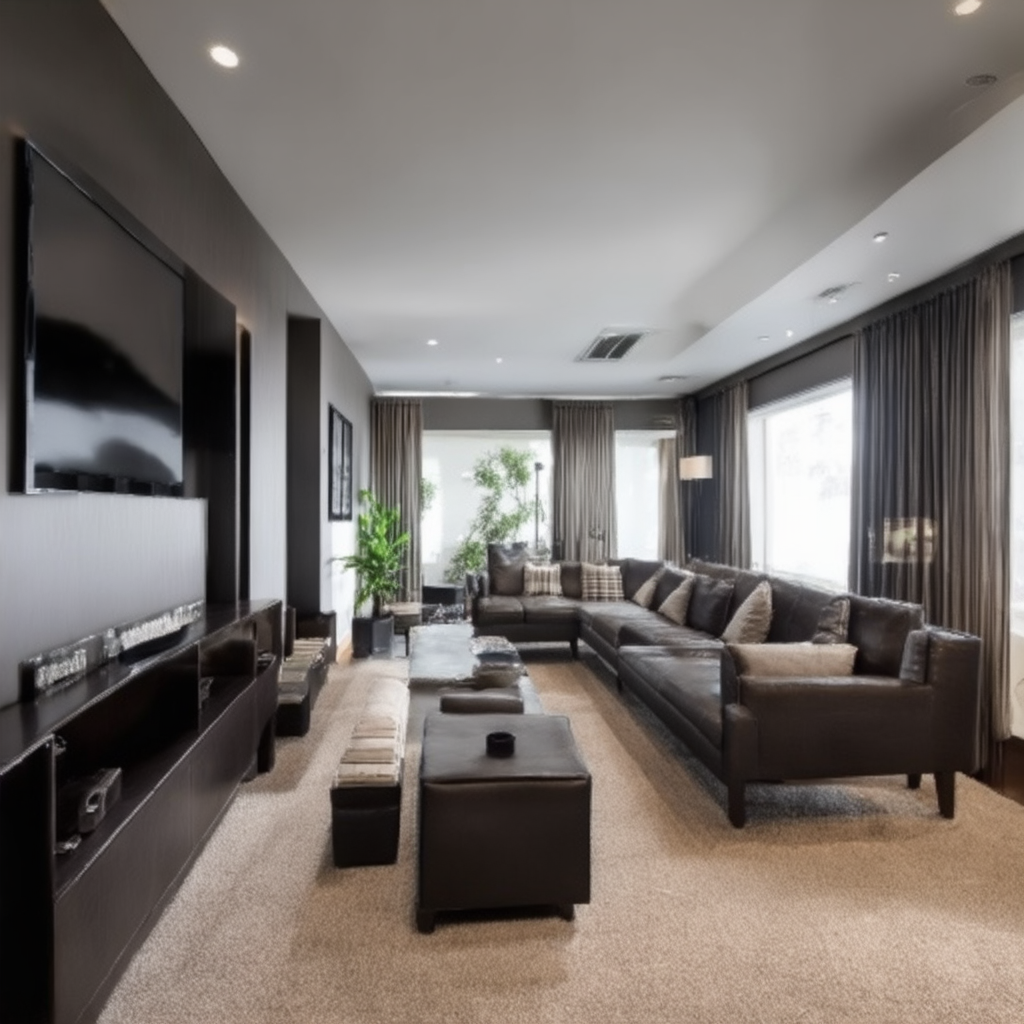

Error: no "view" mailcap rules found for type "image/png"
/usr/bin/xdg-open: 882: www-browser: not found
/usr/bin/xdg-open: 882: links2: not found
/usr/bin/xdg-open: 882: elinks: not found
/usr/bin/xdg-open: 882: links: not found
/usr/bin/xdg-open: 882: lynx: not found
/usr/bin/xdg-open: 882: w3m: not found
xdg-open: no method available for opening '/tmp/tmp880i8wdk.PNG'


In [3]:

prompt = "A professionally designed Lounge featuring a Sleek Charcoal color theme and a Neutral color palette. The Natural Daylight lighting enhances the overall Home Theater atmosphere."

print("Generating image on GPU 1...")
image = pipe(
    prompt=prompt,
    num_inference_steps=24,     
    guidance_scale=7,        
).images[0]

image.show()
image

## 📦 6. Export and Share
Awesome, the images look great! To ensure we don't lose our hard work when the session restarts, let's bundle up our exported `safetensors` model and push it directly to Kaggle Datasets.

In [ ]:
# Optional: Delete the heavy training checkpoints to make the upload instant
!rm -rf /kaggle/working/sd35_lora_model/checkpoint-*

In [17]:
import json
from pathlib import Path

# 1. Define the absolute export directory path
export_dir = Path("/kaggle/working/sd35_lora_model")

# Create the dataset metadata
metadata = {
    "title": "My SD35 Interior Design LoRA Increased Steps",
    "id": "mneebahmd/sd35-interior-lora-increased-steps",  # <--- CHANGE THIS IF NEEDED
    "licenses": [{"name": "CC0-1.0"}]
}

# Use the Path object to cleanly join the filename absolute path
metadata_file = export_dir / "dataset-metadata.json"

with open(metadata_file, "w+", encoding="utf-8") as f:
    json.dump(metadata, f)

print(f"✅ Metadata successfully created at: {metadata_file}")

# 2. Upload to Kaggle Datasets
!kaggle datasets create -p {str(export_dir)} --dir-mode zip

✅ Metadata successfully created at: /kaggle/working/sd35_lora_model/dataset-metadata.json
Starting upload for file logs.zip
100%|█████████████████████████████████████████| 164k/164k [00:00<00:00, 436kB/s]
Upload successful: logs.zip (164KB)
Starting upload for file pytorch_lora_weights.safetensors
100%|██████████████████████████████████████| 35.9M/35.9M [00:00<00:00, 56.2MB/s]
Upload successful: pytorch_lora_weights.safetensors (36MB)
Your private Dataset is being created. Please check progress at https://www.kaggle.com/datasets/mneebahmd/sd35-interior-lora-increased-steps
